# 🫀 Heart Disease Prediction — Notebook 1: EDA & Preprocessing

**Project:** End-to-end ML pipeline for heart disease prediction
**Author:** Rishika Evenjalin
**GitHub:** https://github.com/rishikaevenjalin-bit/heart-disease-prediction-ml
**Dataset:** Cleveland Heart Disease Dataset (303 patients, 13 features)

## 🎯 Objective
Explore the dataset, understand feature distributions and correlations, and prepare clean data for modelling.

## 📋 Contents
1. Environment setup
2. Dataset loading
3. Initial inspection & data quality checks
4. Exploratory data analysis (EDA)
5. Preprocessing (encoding, splitting, scaling)
6. Save cleaned data for downstream notebooks


## 1. Environment Setup

Install all packages we'll need across the project. Running this once ensures consistent versions.

In [15]:
# Install packages that Colab doesn't have by default
!pip install -q imbalanced-learn xgboost shap

# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set global styles for prettier plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Set random seed for reproducibility across the entire project
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Suppress unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

print("✅ Environment ready!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

✅ Environment ready!
NumPy version: 2.0.2
Pandas version: 2.2.3


## 2. Dataset Loading

Loading the Cleveland Heart Disease Dataset from a public URL. This dataset contains 303 patient records with 13 clinical features and 1 binary target variable indicating the presence of heart disease.

**Source:** TensorFlow public storage (Cleveland Heart Disease Dataset)


In [16]:
# Dataset URL
DATA_URL = "https://storage.googleapis.com/download.tensorflow.org/data/heart.csv"

# Load dataset with error handling
try:
    df = pd.read_csv(DATA_URL)
    print(f"✅ Dataset loaded successfully!")
    print(f"📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns")
except Exception as e:
    print(f"❌ Failed to load dataset: {e}")
    raise

# Show the first 5 rows
df.head()


✅ Dataset loaded successfully!
📊 Shape: 303 rows × 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


## 3. Data Quality Checks

Before any analysis, we perform standard checks:
- Data types
- Missing values
- Duplicates
- Class balance
- Basic statistics

In [17]:
# Check data types and non-null counts
print("=" * 60)
print("DATASET INFO")
print("=" * 60)
df.info()

# Check for missing values explicitly
print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✅ No missing values detected")
else:
    print(missing[missing > 0])

# Check for duplicate rows
print("\n" + "=" * 60)
print("DUPLICATES")
print("=" * 60)
duplicates = df.duplicated().sum()
if duplicates == 0:
    print("✅ No duplicate rows detected")
else:
    print(f"⚠️  Found {duplicates} duplicate row(s)")

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(1), int64(12), object(1)
memory usage: 33.3+ KB

MISSING VALUES
✅ No missing values detected

DUPLICATES
✅ No duplicate rows detected


TARGET CLASS DISTRIBUTION
  No Disease (target=0): 220 patients (72.6%)
  Disease (target=1): 83 patients (27.4%)


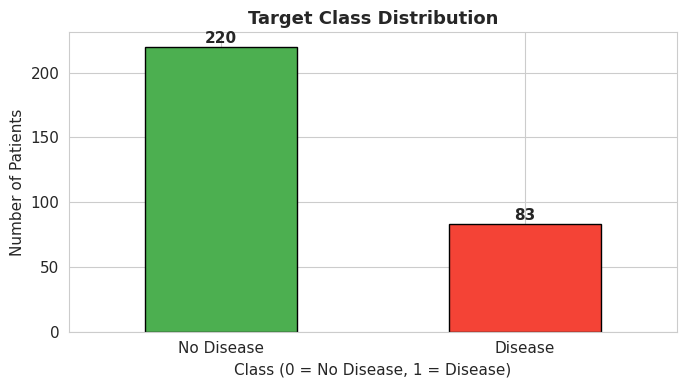

In [18]:
# Check target class balance (crucial for medical ML)
print("=" * 60)
print("TARGET CLASS DISTRIBUTION")
print("=" * 60)

class_counts = df['target'].value_counts().sort_index()
class_pct = df['target'].value_counts(normalize=True).sort_index() * 100

for cls, count in class_counts.items():
    label = "No Disease" if cls == 0 else "Disease"
    print(f"  {label} (target={cls}): {count} patients ({class_pct[cls]:.1f}%)")

# Visual check
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#4CAF50', '#F44336']
class_counts.plot(kind='bar', color=colors, ax=ax, edgecolor='black')
ax.set_title('Target Class Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Class (0 = No Disease, 1 = Disease)')
ax.set_ylabel('Number of Patients')
ax.set_xticklabels(['No Disease', 'Disease'], rotation=0)
for i, v in enumerate(class_counts):
    ax.text(i, v + 3, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 📖 Feature Descriptions

| Feature | Description | Type | Range/Values |
|---|---|---|---|
| **age** | Age of the patient | Numeric | 29–77 years |
| **sex** | Biological sex | Categorical | 0 = Female, 1 = Male |
| **cp** | Chest pain type | Categorical | 1 = Typical angina, 2 = Atypical, 3 = Non-anginal, 4 = Asymptomatic |
| **trestbps** | Resting blood pressure | Numeric | mm Hg |
| **chol** | Serum cholesterol | Numeric | mg/dL |
| **fbs** | Fasting blood sugar > 120 mg/dL | Binary | 0 = False, 1 = True |
| **restecg** | Resting ECG results | Categorical | 0 = Normal, 1 = ST-T abnormality, 2 = LV hypertrophy |
| **thalach** | Max heart rate achieved | Numeric | 71–202 bpm |
| **exang** | Exercise-induced angina | Binary | 0 = No, 1 = Yes |
| **oldpeak** | ST depression induced by exercise | Numeric | 0.0–6.2 |
| **slope** | Slope of peak exercise ST segment | Categorical | 1 = Upsloping, 2 = Flat, 3 = Downsloping |
| **ca** | Number of major vessels (0–3) coloured by fluoroscopy | Numeric | 0–3 |
| **thal** | Thalassemia | Categorical | normal, fixed, reversible |
| **target** | Heart disease diagnosis | Binary | 0 = No Disease, 1 = Disease |

**Note:** The `thal` column contains string values that need encoding before modelling.

## 4. Exploratory Data Analysis

Understanding the data before modelling is critical. We look at:
- Summary statistics for numeric features
- Distributions of key features
- Relationships between features and the target variable
- Correlations across all features

In [19]:
# Summary statistics for numeric features
print("=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
df.describe().round(2)

SUMMARY STATISTICS


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.59,0.68,3.11,131.79,246.55,0.15,0.99,149.19,0.33,1.06,1.59,0.68,0.27
std,9.02,0.47,1.03,17.75,52.18,0.36,0.99,23.17,0.47,1.17,0.62,0.94,0.45
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,0.00
25%,48.00,0.00,2.00,120.00,211.00,0.00,0.00,132.00,0.00,0.00,1.00,0.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,152.00,0.00,0.80,2.00,0.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,165.50,1.00,1.60,2.00,1.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,1.00


### 4.1 Age & Sex Distribution

Age is one of the strongest known risk factors for heart disease.
Let's look at how it's distributed and how it relates to the target.

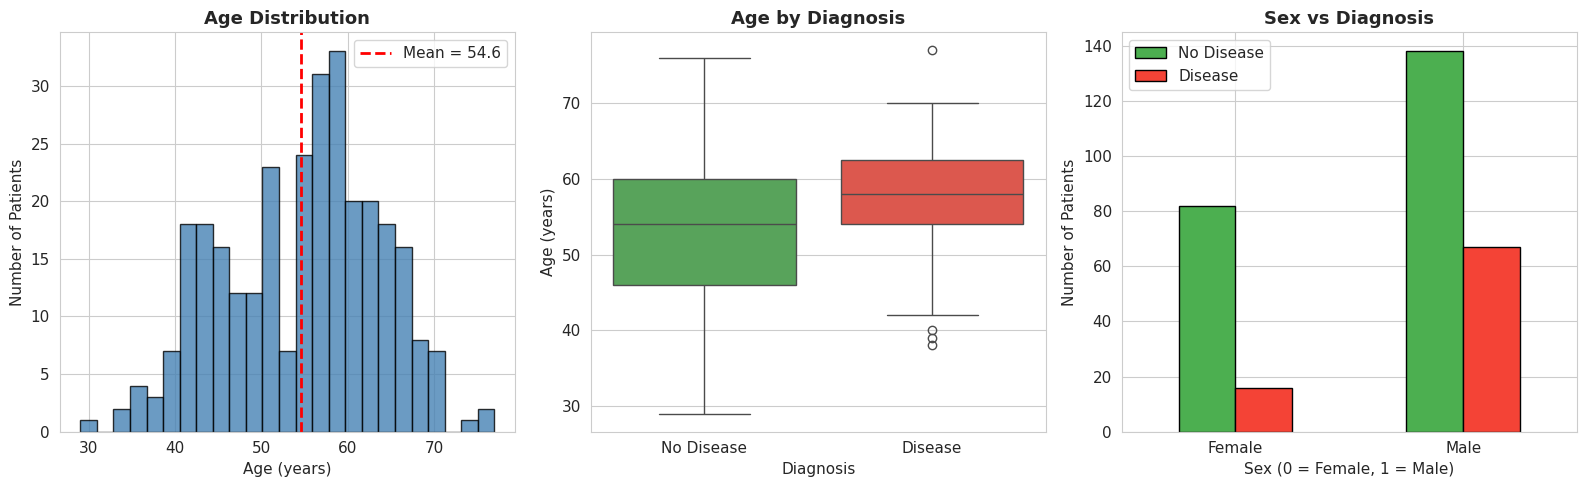


📊 Key insights:
   • Average patient age: 54.6 years (range: 29-77)
   • Male patients: 205 (67.7%)
   • Female patients: 98 (32.3%)


In [20]:
# Age and sex analysis
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Age distribution
axes[0].hist(df['age'], bins=25, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean = {df["age"].mean():.1f}')
axes[0].set_title('Age Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Number of Patients')
axes[0].legend()

# Age by class (boxplot)
sns.boxplot(x='target', y='age', data=df, ax=axes[1], palette=['#4CAF50', '#F44336'])
axes[1].set_title('Age by Diagnosis', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Diagnosis')
axes[1].set_ylabel('Age (years)')
axes[1].set_xticklabels(['No Disease', 'Disease'])

# Sex distribution by class
sex_target = pd.crosstab(df['sex'], df['target'])
sex_target.plot(kind='bar', ax=axes[2], color=['#4CAF50', '#F44336'], edgecolor='black')
axes[2].set_title('Sex vs Diagnosis', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Sex (0 = Female, 1 = Male)')
axes[2].set_ylabel('Number of Patients')
axes[2].set_xticklabels(['Female', 'Male'], rotation=0)
axes[2].legend(['No Disease', 'Disease'])

plt.tight_layout()
plt.show()

# Print key insights
print(f"\n📊 Key insights:")
print(f"   • Average patient age: {df['age'].mean():.1f} years (range: {df['age'].min()}-{df['age'].max()})")
print(f"   • Male patients: {(df['sex'] == 1).sum()} ({(df['sex'] == 1).mean()*100:.1f}%)")
print(f"   • Female patients: {(df['sex'] == 0).sum()} ({(df['sex'] == 0).mean()*100:.1f}%)")

### 4.2 Correlation Heatmap

Correlation shows how features relate to each other and to the target.
Note: we exclude `thal` here since it's still a string. We'll include it after encoding.

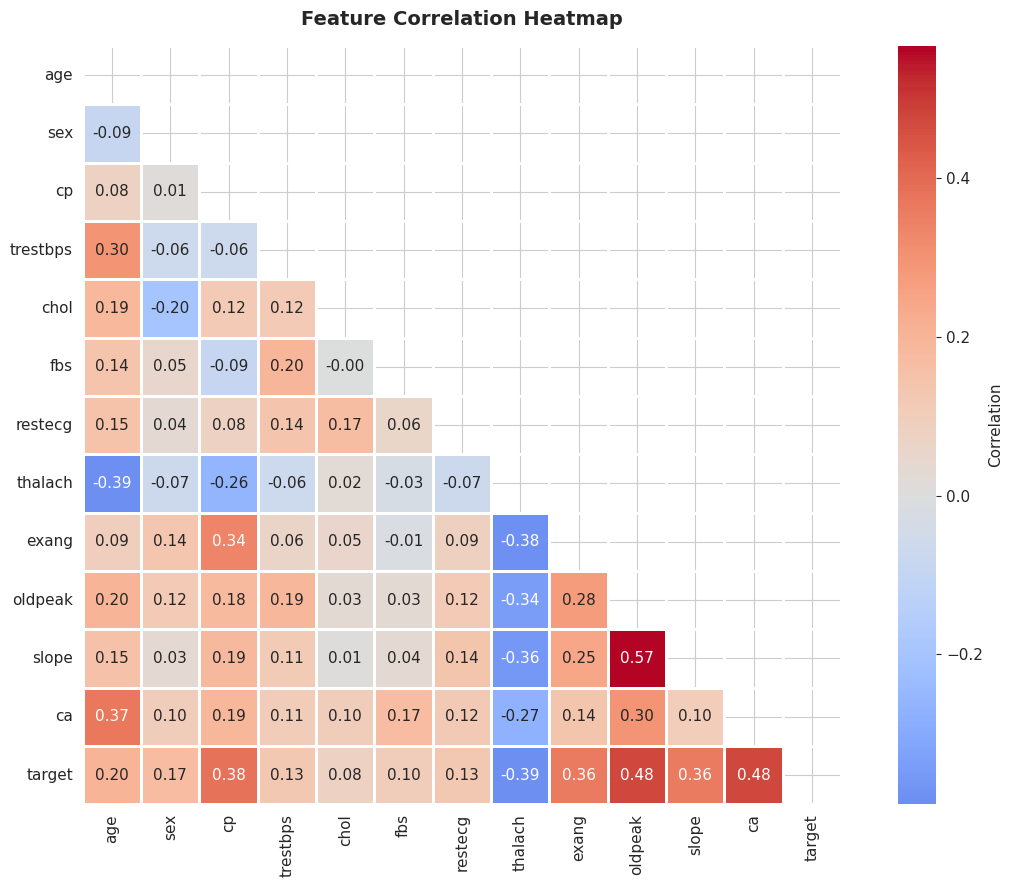


🎯 Strongest correlations with target (heart disease):
   • ca          : +0.477
   • oldpeak     : +0.475
   • thalach     : -0.386
   • cp          : +0.382
   • exang       : +0.361


In [21]:
# Correlation heatmap (excluding thal string column)
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))  # Show only lower triangle
sns.heatmap(numeric_df.corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=1,
            cbar_kws={'label': 'Correlation'},
            mask=mask)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Print strongest correlations with target
target_corr = numeric_df.corr()['target'].drop('target').abs().sort_values(ascending=False)
print("\n🎯 Strongest correlations with target (heart disease):")
for feature, corr in target_corr.head(5).items():
    direction = "+" if numeric_df.corr()['target'][feature] > 0 else "-"
    print(f"   • {feature:12s}: {direction}{corr:.3f}")

### 4.3 Key Clinical Feature Distributions

Looking at features known to be clinically relevant:
- **oldpeak**: ST depression (highest correlation with disease)
- **thalach**: max heart rate (highest negative correlation)
- **cp**: chest pain type
- **ca**: number of major vessels

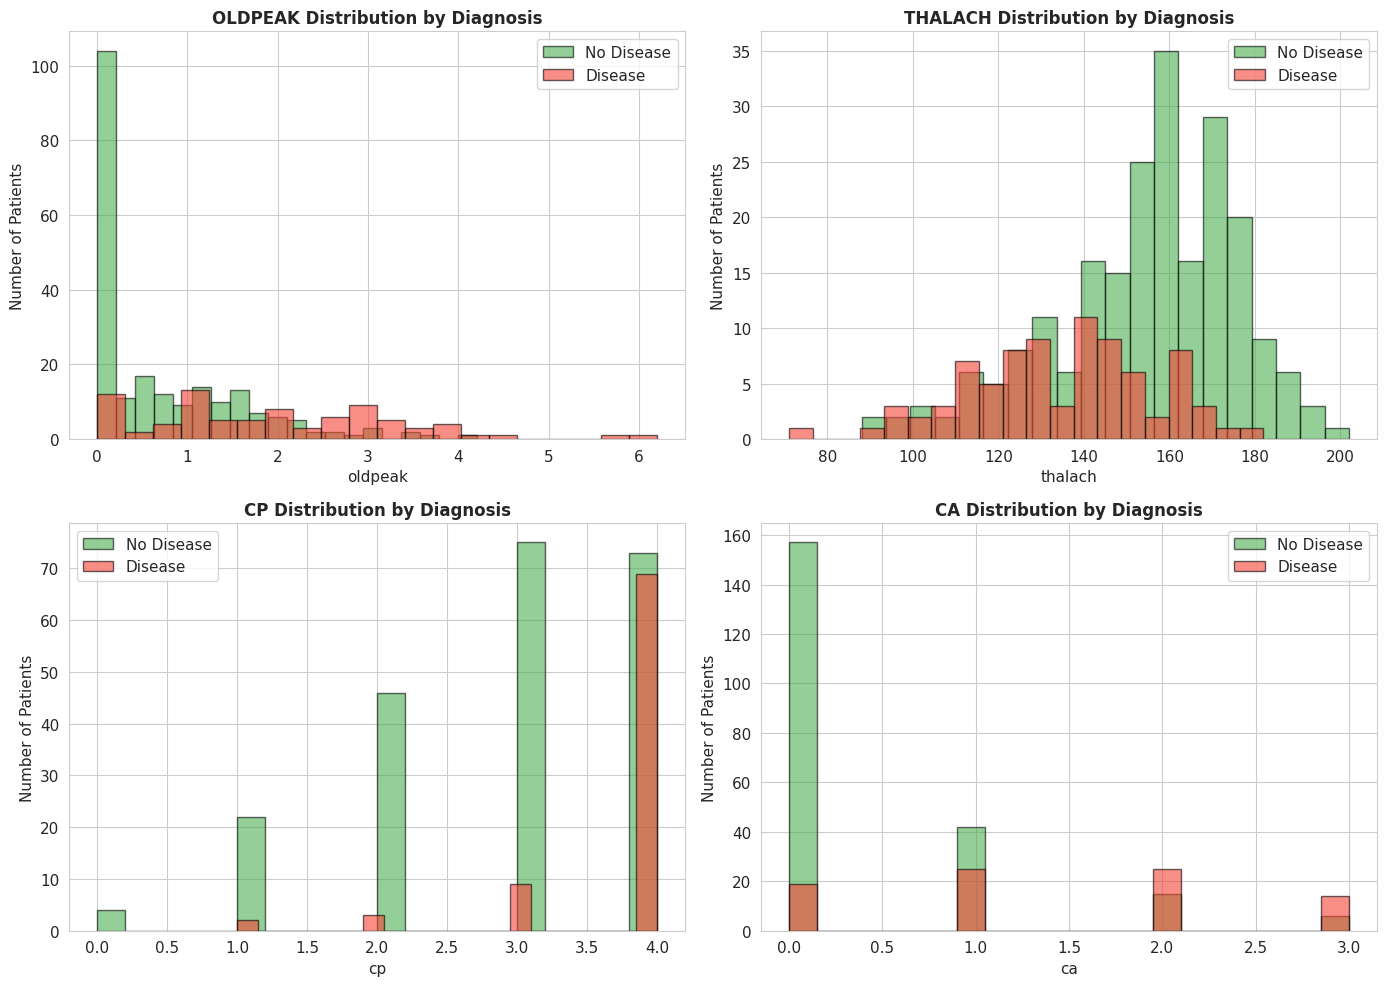

In [22]:
# Key clinical features by target
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
key_features = ['oldpeak', 'thalach', 'cp', 'ca']

for idx, feature in enumerate(key_features):
    ax = axes[idx // 2, idx % 2]

    for target_val, color, label in [(0, '#4CAF50', 'No Disease'),
                                       (1, '#F44336', 'Disease')]:
        subset = df[df['target'] == target_val][feature]
        ax.hist(subset, bins=20, alpha=0.6, color=color, label=label, edgecolor='black')

    ax.set_title(f'{feature.upper()} Distribution by Diagnosis', fontsize=12, fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Number of Patients')
    ax.legend()

plt.tight_layout()
plt.show()

## 5. Preprocessing

Three preprocessing steps needed before modelling:
1. **Encode the `thal` column** (convert text to numeric)
2. **Split** into training and testing sets (80/20)
3. **Scale** features so they're on the same scale (needed for LR, SVM, ANN)

**Note:** Scaling is fit on training data ONLY, then applied to both train and test.
This prevents data leakage from the test set into training.

In [23]:
# Encode the 'thal' column safely
print("Before encoding:")
print(f"  Data type: {df['thal'].dtype}")
print(f"  Unique values: {df['thal'].unique()}")

# Convert to string first (handles any weird cases)
df['thal'] = df['thal'].astype(str).str.lower().str.strip()

# Comprehensive mapping (handles text AND numeric string versions)
thal_mapping = {
    'normal': 0,
    'fixed': 1,
    'reversible': 2,
    '0': 0,
    '1': 1,
    '2': 2,
    '3': 2,       # Some datasets code 'reversible' as 3
    'nan': 0,
    '': 0
}

df['thal'] = df['thal'].map(thal_mapping)

# Sanity check — no NaN should remain
if df['thal'].isna().any():
    print(f"⚠️  Found NaN in thal — filling with mode")
    df['thal'] = df['thal'].fillna(df['thal'].mode()[0])

# Ensure integer type
df['thal'] = df['thal'].astype(int)

print("\nAfter encoding:")
print(f"  Data type: {df['thal'].dtype}")
print(f"  Unique values: {sorted(df['thal'].unique())}")
print(f"  Value counts: {df['thal'].value_counts().to_dict()}")
print(f"\n✅ Encoding complete — no NaN in dataset: {df.isna().sum().sum() == 0}")

Before encoding:
  Data type: object
  Unique values: ['fixed' 'normal' 'reversible' '1' '2']

After encoding:
  Data type: int64
  Unique values: [np.int64(0), np.int64(1), np.int64(2)]
  Value counts: {0: 168, 2: 116, 1: 19}

✅ Encoding complete — no NaN in dataset: True


In [24]:
from sklearn.model_selection import train_test_split

# Separate features (X) from target (y)
X = df.drop('target', axis=1)
y = df['target']

# Stratified split — keeps class balance the same in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y   # ← This is important for imbalanced datasets
)

print("=" * 60)
print("TRAIN/TEST SPLIT")
print("=" * 60)
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Testing set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")

print("\nClass balance preserved (thanks to stratify=y):")
print(f"  Training  → {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"  Testing   → {y_test.value_counts(normalize=True).round(3).to_dict()}")

TRAIN/TEST SPLIT
Training set: 242 samples (80%)
Testing set:  61 samples (20%)

Class balance preserved (thanks to stratify=y):
  Training  → {0: 0.727, 1: 0.273}
  Testing   → {0: 0.721, 1: 0.279}


In [25]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit on TRAINING data only, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Keep feature names for later interpretability (SHAP needs them)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("=" * 60)
print("FEATURE SCALING")
print("=" * 60)
print(f"✅ Scaler fitted on training data only (no leakage)")
print(f"✅ Both train and test transformed")
print(f"\nBefore scaling (train set stats):")
print(f"  Mean range:  {X_train.mean().min():.1f} to {X_train.mean().max():.1f}")
print(f"  Std range:   {X_train.std().min():.1f} to {X_train.std().max():.1f}")
print(f"\nAfter scaling (train set stats):")
print(f"  Mean ≈ 0:    {X_train_scaled.mean().mean():.6f}")
print(f"  Std ≈ 1:     {X_train_scaled.std().mean():.6f}")
print(f"\n✅ Any NaN in scaled data? {X_train_scaled.isna().any().any()}")

FEATURE SCALING
✅ Scaler fitted on training data only (no leakage)
✅ Both train and test transformed

Before scaling (train set stats):
  Mean range:  0.2 to 248.9
  Std range:   0.4 to 53.8

After scaling (train set stats):
  Mean ≈ 0:    -0.000000
  Std ≈ 1:     1.002073

✅ Any NaN in scaled data? False


## 6. Save Preprocessed Data

Save the cleaned and scaled data so downstream notebooks (03, 04, 05) can load it directly without re-running preprocessing.

In [26]:
import os

# Create output directory if it doesn't exist
os.makedirs('outputs', exist_ok=True)

# Save preprocessed data
X_train_scaled.to_csv('outputs/X_train_scaled.csv', index=False)
X_test_scaled.to_csv('outputs/X_test_scaled.csv', index=False)
y_train.to_csv('outputs/y_train.csv', index=False)
y_test.to_csv('outputs/y_test.csv', index=False)

# Also save the fitted scaler for the Streamlit app later
import pickle
os.makedirs('models', exist_ok=True)
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Preprocessed data saved to outputs/")
print("✅ Scaler saved to models/scaler.pkl")
print("\nFiles created:")
print("  • outputs/X_train_scaled.csv")
print("  • outputs/X_test_scaled.csv")
print("  • outputs/y_train.csv")
print("  • outputs/y_test.csv")
print("  • models/scaler.pkl")

✅ Preprocessed data saved to outputs/
✅ Scaler saved to models/scaler.pkl

Files created:
  • outputs/X_train_scaled.csv
  • outputs/X_test_scaled.csv
  • outputs/y_train.csv
  • outputs/y_test.csv
  • models/scaler.pkl


## ✅ Notebook 1 Complete!

### Summary of what we did:
1. ✅ Loaded 303 patients with 14 features
2. ✅ Confirmed no missing values or duplicates
3. ✅ Explored age, sex, and key clinical features
4. ✅ Identified strongest predictors via correlation
5. ✅ Encoded `thal` column safely
6. ✅ Stratified train/test split (242/61)
7. ✅ Standardized features (fit on train only)
8. ✅ Saved preprocessed data for downstream use

### Next → Notebook 2: Traditional Machine Learning Models
We'll train Logistic Regression, Random Forest, XGBoost, and SVM.

## ✅ Notebook 1 Complete!

### Summary of what we did:
1. ✅ Loaded 303 patients with 14 features
2. ✅ Confirmed no missing values or duplicates
3. ✅ Explored age, sex, and key clinical features
4. ✅ Identified strongest predictors via correlation
5. ✅ Encoded `thal` column safely
6. ✅ Stratified train/test split (242/61)
7. ✅ Standardized features (fit on train only)
8. ✅ Saved preprocessed data for downstream use

### Next → Notebook 2: Traditional Machine Learning Models
We'll train Logistic Regression, Random Forest, XGBoost, and SVM.